In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx

import ai_surrogate_models as ai
from scattering_simulation import prepare_lens_scattering_solver
import topology_parametrization
import field_postprocessing
from manufacturing_constraints import too_thin_area

import optax
from mutax import differential_evolution

from field_plotter import visible_amplitude_colormap
import matplotlib.pyplot as plt

**Define some hyperparameters**

In [2]:
period = 2000
p_red = period / 650
p_green = period / 550
p_blue = period / 450

focal_distance = 3500

**Define topology and load models**

In [7]:
topology = topology_parametrization.CylindricalPillar(grid_size=2, symmetry_type='bayer')
min_width = 0.1
red_model = ai.load_model(
    filename='ai_models/mlp_red_cylinder.msgpack', model_type=ai.ScatteringMLP,
    din=3, n_modes=29, n_out_channels=4, hidden_dims=[256] * 6
)
green_model = ai.load_model(
    filename='ai_models/mlp_green_cylinder.msgpack', model_type=ai.ScatteringMLP,
    din=3, n_modes=45, n_out_channels=4, hidden_dims=[256] * 6
)
blue_model = ai.load_model(
    filename='ai_models/mlp_blue_cylinder.msgpack', model_type=ai.ScatteringMLP,
    din=3, n_modes=61, n_out_channels=4, hidden_dims=[256] * 6
)

In [3]:
n_px = 100
topology = topology_parametrization.GaussianField(n_px, sigma=16, symmetry_type='main_diagonal')
min_width = 140
min_width_px = round(min_width * n_px / period)
min_width_px = (min_width_px // 2) * 2 + 1
print('Min width in pixels:', min_width_px, 'which corresponds to', min_width_px * period / n_px, 'nm')

Min width in pixels: 7 which corresponds to 140.0 nm


In [4]:
common_fno_kwargs = {'model_type': ai.ScatteringFNO, 'dout': 4, 'hidden_dims': [64] * 7, 'modes': 16, 'activation': nnx.gelu}
red_model = ai.load_model('ai_models/fno_red_freeform.msgpack', **common_fno_kwargs)
green_model = ai.load_model('ai_models/fno_green_freeform.msgpack', **common_fno_kwargs)
blue_model = ai.load_model('ai_models/fno_blue_freeform.msgpack', **common_fno_kwargs)

**Prepare simulation functions**

In [4]:
common_sim_kwargs = {'period': 2000, 'lens_thickness': 600, 'substrate_thickness': 500,
                     'approximate_number_of_terms': 600, 'propagate_by_distance': 0}
red_sim, red_basis = prepare_lens_scattering_solver(wavelength=650, **common_sim_kwargs)
green_sim, green_basis = prepare_lens_scattering_solver(wavelength=550, **common_sim_kwargs)
blue_sim, blue_basis = prepare_lens_scattering_solver(wavelength=450, **common_sim_kwargs)

print(red_basis.shape, green_basis.shape, blue_basis.shape)

(2, 29) (2, 45) (2, 61)


**Test model accuracy**

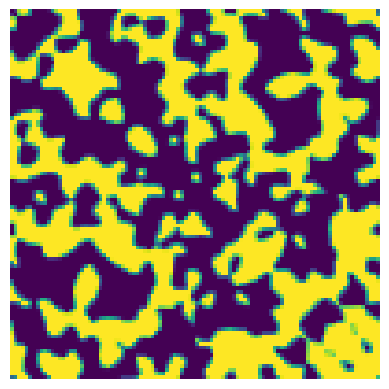

In [6]:
# test_params = jnp.array([0.2, 0.5, 0.8])
test_params = jax.random.uniform(jax.random.key(1), topology.n_geometrical_parameters, minval=topology.minval, maxval=topology.maxval)
test_pattern = topology(test_params)
plt.imshow(test_pattern)
plt.axis('off')
plt.show()

In [ ]:
# for MLP
pred_amps_red = red_model(test_params).squeeze().T
true_amps_red = red_sim(test_pattern)[:red_basis.shape[-1]].T
pred_amps_green = green_model(test_params).squeeze().T
true_amps_green = green_sim(test_pattern)[:green_basis.shape[-1]].T
pred_amps_blue = blue_model(test_params).squeeze().T
true_amps_blue = blue_sim(test_pattern)[:blue_basis.shape[-1]].T

In [16]:
# for FNO
pred_amps_red = red_model(test_pattern[None]).squeeze()
true_amps_red = red_sim(test_pattern)[:red_basis.shape[-1]].T
pred_amps_green = green_model(test_pattern[None]).squeeze()
true_amps_green = green_sim(test_pattern)[:green_basis.shape[-1]].T
pred_amps_blue = blue_model(test_pattern[None]).squeeze()
true_amps_blue = blue_sim(test_pattern)[:blue_basis.shape[-1]].T

pred_amps_red = field_postprocessing.extract_amps_from_fields(pred_amps_red, red_basis).T
pred_amps_green = field_postprocessing.extract_amps_from_fields(pred_amps_green, green_basis).T
pred_amps_blue = field_postprocessing.extract_amps_from_fields(pred_amps_blue, blue_basis).T

In [17]:
print(pred_amps_red.shape, true_amps_red.shape)
print(pred_amps_green.shape, true_amps_green.shape)
print(pred_amps_blue.shape, true_amps_blue.shape)

(4, 29) (4, 29)
(4, 45) (4, 45)
(4, 61) (4, 61)


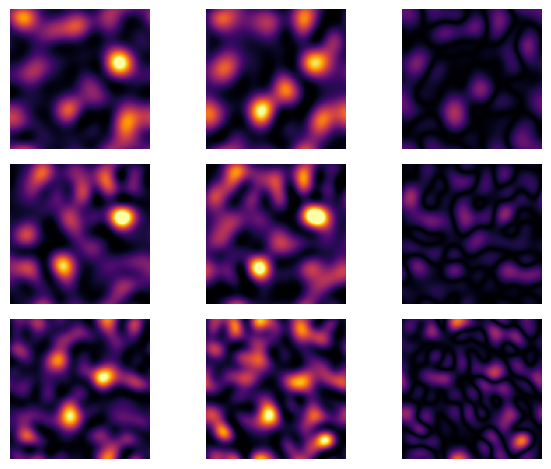

In [21]:
fig, ax = plt.subplots(3, 3)

vmin = 0
vmax = 3.5

pred_amps_red_normalized = field_postprocessing.normalize_power(pred_amps_red, p_red, red_basis)
pred_amps_green_normalized = field_postprocessing.normalize_power(pred_amps_green, p_green, green_basis)
pred_amps_blue_normalized = field_postprocessing.normalize_power(pred_amps_blue, p_blue, blue_basis)

true_red = field_postprocessing.amps_to_intensity_map(true_amps_red[:2], red_basis, p_red)
true_green = field_postprocessing.amps_to_intensity_map(true_amps_green[:2], green_basis, p_green)
true_blue = field_postprocessing.amps_to_intensity_map(true_amps_blue[:2], blue_basis, p_blue)

pred_red = field_postprocessing.amps_to_intensity_map(pred_amps_red_normalized[:2], red_basis, p_red)
pred_green = field_postprocessing.amps_to_intensity_map(pred_amps_green_normalized[:2], green_basis, p_green)
pred_blue = field_postprocessing.amps_to_intensity_map(pred_amps_blue_normalized[:2], blue_basis, p_blue)
# pred_red = field_postprocessing.amps_to_intensity_map(pred_amps_red[:2], red_basis, p_red)
# pred_green = field_postprocessing.amps_to_intensity_map(pred_amps_green[:2], green_basis, p_green)
# pred_blue = field_postprocessing.amps_to_intensity_map(pred_amps_blue[:2], blue_basis, p_blue)

ax[0, 0].imshow(true_red, cmap='inferno', vmin=vmin, vmax=vmax)
ax[0, 1].imshow(pred_red, cmap='inferno', vmin=vmin, vmax=vmax)
ax[0, 2].imshow(np.abs(true_red - pred_red), cmap='inferno', vmin=vmin, vmax=vmax)

ax[1, 0].imshow(true_green, cmap='inferno', vmin=vmin, vmax=vmax)
ax[1, 1].imshow(pred_green, cmap='inferno', vmin=vmin, vmax=vmax)
ax[1, 2].imshow(np.abs(true_green - pred_green), cmap='inferno', vmin=vmin, vmax=vmax)

ax[2, 0].imshow(true_blue, cmap='inferno', vmin=vmin, vmax=vmax)
ax[2, 1].imshow(pred_blue, cmap='inferno', vmin=vmin, vmax=vmax)
ax[2, 2].imshow(np.abs(true_blue - pred_blue), cmap='inferno', vmin=vmin, vmax=vmax)

for ax_i in ax.flatten():
    ax_i.set_axis_off()
plt.tight_layout()
plt.show()

**Prepare efficiency functions**

In [5]:
def params_to_normalized_amps_xy_rgb(params, sim_func_red, sim_func_green, sim_func_blue):
    amps_red = sim_func_red(params).squeeze()[:red_basis.shape[1]].T
    amps_green = sim_func_green(params).squeeze()[:green_basis.shape[1]].T
    amps_blue = sim_func_blue(params).squeeze()[:blue_basis.shape[1]].T

    amps_red = field_postprocessing.normalize_power(amps_red, p_red, red_basis)[:2]
    amps_green = field_postprocessing.normalize_power(amps_green, p_green, green_basis)[:2]
    amps_blue = field_postprocessing.normalize_power(amps_blue, p_blue, blue_basis)[:2]

    amps_red = field_postprocessing.propagate_amps_in_free_space(amps_red, focal_distance, red_basis, 650, period)
    amps_green = field_postprocessing.propagate_amps_in_free_space(amps_green, focal_distance, green_basis, 550, period)
    amps_blue = field_postprocessing.propagate_amps_in_free_space(amps_blue, focal_distance, blue_basis, 450, period)

    return amps_red, amps_green, amps_blue

def params_to_focused_powers(params, true_sim=True):
    if true_sim:
        sim_funcs = (lambda x: red_sim(topology(x)), lambda x: green_sim(topology(x)), lambda x: blue_sim(topology(x)))
    else:
        if isinstance(red_model, ai.ScatteringMLP):
            sim_funcs = (red_model, green_model, blue_model)
        elif isinstance(red_model, ai.ScatteringFNO):
            sim_funcs = (
                lambda x: field_postprocessing.extract_amps_from_fields(red_model(topology(x)[None])[0], red_basis),
                lambda x: field_postprocessing.extract_amps_from_fields(green_model(topology(x)[None])[0], green_basis),
                lambda x: field_postprocessing.extract_amps_from_fields(blue_model(topology(x)[None])[0], blue_basis)
            )

    amps_red, amps_green, amps_blue = params_to_normalized_amps_xy_rgb(params, *sim_funcs)

    red_power = field_postprocessing.calculate_focused_power(amps_red, p_red, red_basis, relative_focal_point=(0.25, 0.25))
    green_power = (
        field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.25, 0.75))
        + field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.75, 0.25))
    )
    blue_power = field_postprocessing.calculate_focused_power(amps_blue, p_blue, blue_basis, relative_focal_point=(0.75, 0.75))

    return jnp.array([red_power, green_power, blue_power])

**Lens AI Optimization**

In [7]:
# for MLP
min_width = 0.1

def objective_function_to_minimize(x):
    # eff = jnp.mean(params_to_focused_powers(x, true_sim=False))
    eff = jnp.min(params_to_focused_powers(x, true_sim=False))
    invalid_pillar_lengths = jnp.maximum(1 - jnp.abs(x - min_width / 2) / (min_width / 2), 0)
    invalid = jnp.mean(invalid_pillar_lengths)
    return 0.1 * invalid - eff

opt_res = differential_evolution(
    objective_function_to_minimize,
    [(0, 1)] * topology.n_geometrical_parameters,
    polish=False,
    disp=True
)

print(opt_res.x)

differential_evolution step 1: f(x)=-0.2917543351650238
differential_evolution step 2: f(x)=-0.3127465844154358
differential_evolution step 3: f(x)=-0.3231782019138336
differential_evolution step 4: f(x)=-0.33103883266448975
differential_evolution step 5: f(x)=-0.33103883266448975
differential_evolution step 6: f(x)=-0.33103883266448975
differential_evolution step 7: f(x)=-0.33106765151023865
differential_evolution step 8: f(x)=-0.3346523940563202
differential_evolution step 9: f(x)=-0.3350345194339752
differential_evolution step 10: f(x)=-0.3350345194339752
differential_evolution step 11: f(x)=-0.3350345194339752
[0.98003083 0.09466168 0.        ]


In [ ]:
# for FNO
class FixedPopsize:
    def __init__(self, target_total_pop):
        self.target = target_total_pop

    def __mul__(self, other):
        return int(self.target)

    def __rmul__(self, other):
        return int(self.target)

    def __imul__(self, other):
        return int(self.target)

@jax.jit
def objective_function_to_minimize(x):
    eff = jnp.mean(params_to_focused_powers(x, true_sim=False))
    # eff = jnp.min(params_to_focused_powers(x, true_sim=False))
    invalid = too_thin_area(topology(x), min_width_px)
    invalid = 1 - jnp.abs(1 - invalid) ** 4
    return invalid - eff

opt_res = differential_evolution(
    objective_function_to_minimize,
    [(-1, 1)] * topology.n_geometrical_parameters,
    popsize=FixedPopsize(50),
    polish=False,
    disp=True,
    tol=0,
    atol=1e-6,
    maxiter=100
)

print(opt_res.x)

In [16]:
print(params_to_focused_powers(opt_res.x, true_sim=False))
print(params_to_focused_powers(opt_res.x, true_sim=True))

[0.22024545 0.5360977  0.352902  ]
[0.19052376 0.44567734 0.26486197]


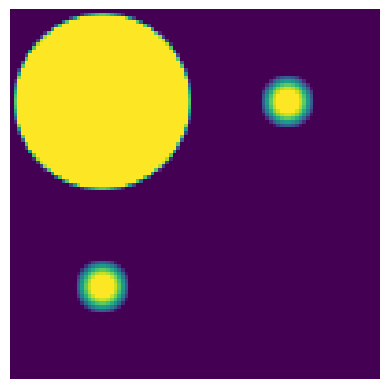

In [8]:
plt.imshow(topology(opt_res.x))
plt.axis('off')
plt.show()

In [9]:
x_init = opt_res.x.copy()
learning_rate = 1e-2
n_steps = 100

loss_value_and_grad_fn = jax.value_and_grad(objective_function_to_minimize)

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(x_init)

@jax.jit
def step(x, opt_state):
    loss, grad = loss_value_and_grad_fn(x)
    updates, opt_state = optimizer.update(grad, opt_state)
    x = optax.apply_updates(x, updates)
    x = jnp.clip(x, topology.minval, topology.maxval)
    return x, opt_state, loss, grad

x = x_init
max_f = -1e10
best_x = x

for i in range(n_steps):
    new_x, opt_state, loss, grad = step(x, opt_state)
    # print(i, repr(x), repr(new_x), loss, repr(grad), sep='\n')

    if loss > max_f:
        max_f = loss
        best_x = x

    print(i, loss, sep='\t')
    x = new_x

0	-0.3350856
1	-0.3171716
2	-0.33160955
3	-0.33002582
4	-0.32919183
5	-0.33321047
6	-0.335015
7	-0.33286428
8	-0.3315692
9	-0.332983
10	-0.33476612
11	-0.33463627
12	-0.33327216
13	-0.33325872
14	-0.33423004
15	-0.3349833
16	-0.33467278
17	-0.3338462
18	-0.3339241
19	-0.3345279
20	-0.33499748
21	-0.3349245
22	-0.3344902
23	-0.33442488
24	-0.3347781
25	-0.33503702
26	-0.3347535
27	-0.33468306
28	-0.33473045
29	-0.3349753
30	-0.3350374
31	-0.33493996
32	-0.33480448
33	-0.33487734
34	-0.33504143
35	-0.33486748
36	-0.33497205
37	-0.33492795
38	-0.33500838
39	-0.33499917
40	-0.33504462
41	-0.33498305
42	-0.33500817
43	-0.33507907
44	-0.3350022
45	-0.33503708
46	-0.3350215
47	-0.3350627
48	-0.335042
49	-0.3350683
50	-0.33504912
51	-0.33506978
52	-0.3350921
53	-0.33492103
54	-0.33506173
55	-0.33507204
56	-0.3350922
57	-0.33508983
58	-0.3348447
59	-0.33507848
60	-0.33509076
61	-0.33508962
62	-0.33503675
63	-0.33508462
64	-0.3350934
65	-0.33509234
66	-0.3350853
67	-0.33490303
68	-0.33509398
69	

In [20]:
print(params_to_focused_powers(x, true_sim=False))
print(params_to_focused_powers(x, true_sim=True))

[0.5083139  0.6225045  0.64522773]
[0.40124688 0.48891354 0.43476328]


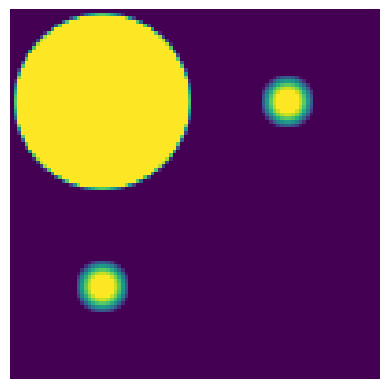

In [10]:
plt.imshow(topology(x))
plt.axis('off')
plt.show()

**Final Rigorous Optimization**

In [11]:
# x_init = opt_res.x
x_init = x

learning_rate = 1e-2
n_steps = 30

In [12]:
def objective_function_to_maximize(x):
    eff = jnp.mean(params_to_focused_powers(x, true_sim=True))
    invalid_pillar_lengths = jnp.maximum(1 - jnp.abs(x - min_width / 2) / (min_width / 2), 0)
    invalid = jnp.mean(invalid_pillar_lengths)
    return eff - 0.1 * invalid

loss_value_and_grad_fn = jax.value_and_grad(objective_function_to_maximize)

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(x_init)

def step(x, opt_state):
    loss, grad = loss_value_and_grad_fn(x)
    updates, opt_state = optimizer.update(-grad, opt_state)
    x = optax.apply_updates(x, updates)
    x = jnp.clip(x, topology.minval, topology.maxval)
    return x, opt_state, loss, grad

x = x_init
max_f = -1e10
best_x = x

for i in range(n_steps):
    new_x, opt_state, loss, grad = step(x, opt_state)
    # print(i, repr(x), repr(new_x), loss, repr(grad), sep='\n')

    if loss > max_f:
        max_f = loss
        best_x = x

    print(i, loss, sep='\t')
    x = new_x

0	0.449435
1	0.43320486
2	0.44984046
3	0.4527206
4	0.44488516
5	0.4458365
6	0.45090485
7	0.45337614
8	0.45251
9	0.45134208
10	0.4506124
11	0.45118034
12	0.452553
13	0.45361027
14	0.4538409
15	0.45185885
16	0.44810867
17	0.44521105
18	0.4442148
19	0.4458789
20	0.44929242
21	0.4524189
22	0.45366496
23	0.4528663
24	0.45082298
25	0.44948804
26	0.4499375
27	0.45184383
28	0.45332938
29	0.45380992


In [14]:
print(best_x)

[0.9925493 0.0918164 0.       ] [0.9794463  0.09438191 0.        ]


In [22]:
def objective_function_to_maximize(x):
    eff = jnp.mean(params_to_focused_powers(x, true_sim=True))
    invalid = too_thin_area(topology(x), min_width_px)
    # return eff - 5.0 * invalid
    invalid = 1 - jnp.abs(1 - invalid) ** 4
    return invalid - eff

loss_value_and_grad_fn = jax.value_and_grad(objective_function_to_maximize)

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(x_init)

def step(x, opt_state):
    loss, grad = loss_value_and_grad_fn(x)
    updates, opt_state = optimizer.update(-grad, opt_state)
    x = optax.apply_updates(x, updates)
    x = jnp.clip(x, topology.minval, topology.maxval)
    return x, opt_state, loss, grad

x = x_init
max_f = -1e10
best_x = x

for i in range(n_steps):
    new_x, opt_state, loss, grad = step(x, opt_state)

    if loss > max_f:
        max_f = loss
        best_x = x

    print(i, loss, sep='\t')
    x = new_x


KeyboardInterrupt



In [ ]:
print(best_x, opt_res.x)
print(objective_function_to_maximize(best_x), objective_function_to_maximize(opt_res.x))

**Visualize results**

In [31]:
# final_params = jnp.array([0.9936472, 0.09133924, 0.])
# final_params = best_x
final_params = x

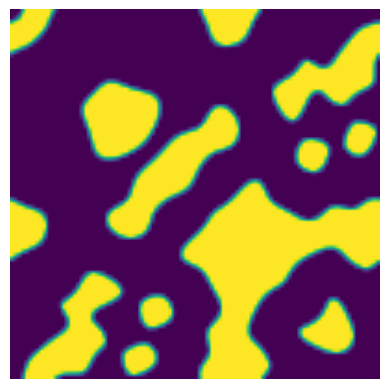

In [32]:
plt.imshow(topology(final_params, 500))
plt.axis('off')
plt.show()

In [33]:
amps_red, amps_green, amps_blue = params_to_normalized_amps_xy_rgb(topology(final_params), red_sim, green_sim, blue_sim)

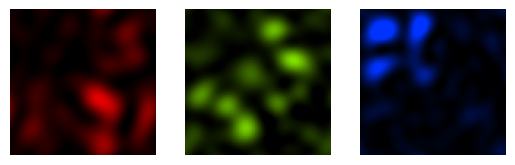

In [34]:
fig, ax = plt.subplots(1, 3)
vmin = 0
vmax = 5
ax[0].imshow(field_postprocessing.amps_to_intensity_map(amps_red, red_basis, p_red), cmap=visible_amplitude_colormap(650), vmax=vmax, vmin=vmin)
ax[1].imshow(field_postprocessing.amps_to_intensity_map(amps_green, green_basis, p_green), cmap=visible_amplitude_colormap(550), vmax=vmax, vmin=vmin)
ax[2].imshow(field_postprocessing.amps_to_intensity_map(amps_blue, blue_basis, p_blue), cmap=visible_amplitude_colormap(450), vmax=vmax, vmin=vmin)

for ax_i in ax.flatten():
    ax_i.set_axis_off()
plt.show()

**Full Spectral Performance Analysis**

In [35]:
def calculate_focused_powers_single_wavelength(pattern, wavelength):
    sim_func, basis = prepare_lens_scattering_solver(wavelength, **common_sim_kwargs)
    amps = sim_func(pattern).squeeze()[:basis.shape[1]].T[:2]
    amps = field_postprocessing.propagate_amps_in_free_space(amps, focal_distance, basis, wavelength, period)

    red_detector_power = field_postprocessing.calculate_focused_power(amps, period / wavelength, basis, relative_focal_point=(0.25, 0.25))
    green_detector1_power = field_postprocessing.calculate_focused_power(amps, period / wavelength, basis, relative_focal_point=(0.25, 0.75))
    green_detector2_power = field_postprocessing.calculate_focused_power(amps, period / wavelength, basis, relative_focal_point=(0.75, 0.25))
    blue_detector_power = field_postprocessing.calculate_focused_power(amps, period / wavelength, basis, relative_focal_point=(0.75, 0.75))

    return red_detector_power, green_detector1_power, green_detector2_power, blue_detector_power, amps

In [36]:
sweep_wavelengths = np.arange(400, 700, 25)
sweep_wavelengths[0] = 405
print(sweep_wavelengths)

[405 425 450 475 500 525 550 575 600 625 650 675]


In [37]:
all_amps = []
detector_wise_powers = []
final_pattern = topology(final_params)

for i, wl in enumerate(sweep_wavelengths):
    print('Progress:', round(100 * i / len(sweep_wavelengths)), '%')
    result = calculate_focused_powers_single_wavelength(final_pattern, wl)
    detector_wise_powers.append(result[:4])
    all_amps.append(result[-1])

detector_wise_powers = np.array(detector_wise_powers)

Progress: 0 %
Progress: 8 %
Progress: 17 %
Progress: 25 %
Progress: 33 %
Progress: 42 %
Progress: 50 %
Progress: 58 %
Progress: 67 %
Progress: 75 %
Progress: 83 %
Progress: 92 %


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (12, 2) + inhomogeneous part.

In [44]:
print(detector_wise_powers)

[[0.18719259 0.11037906 0.11813727 0.32022566]
 [0.11082064 0.13566463 0.12103496 0.36641744]
 [0.08417701 0.08912857 0.08631663 0.553791  ]
 [0.11061657 0.14571719 0.11395648 0.40756437]
 [0.13923869 0.1850731  0.13800253 0.2689476 ]
 [0.14243565 0.2610426  0.19563736 0.17742689]
 [0.11608316 0.28368694 0.25971565 0.12512247]
 [0.19074987 0.23710407 0.23214081 0.11624265]
 [0.24589492 0.21032016 0.17948103 0.09308975]
 [0.2773093  0.19160606 0.16937448 0.08395059]
 [0.37576422 0.17010365 0.16835497 0.05725773]
 [0.21540724 0.16301817 0.13335359 0.16352619]]


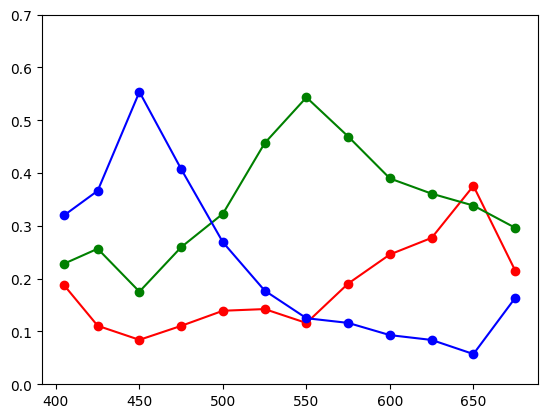

In [45]:
plt.plot(sweep_wavelengths, detector_wise_powers[:, 0], '-o', color='red')
plt.plot(sweep_wavelengths, detector_wise_powers[:, 1] + detector_wise_powers[:, 2], '-o', color='green')
plt.plot(sweep_wavelengths, detector_wise_powers[:, 3], '-o', color='blue')
plt.ylim(0, 0.7)
plt.show()

**Test how rigorous local optimization converges with no AI-optimized initial guess**

In [11]:
# find good and bad seeds
def objective_function_to_maximize(x):
    eff = jnp.mean(params_to_focused_powers(x, true_sim=True))
    invalid_pillar_lengths = jnp.maximum(1 - jnp.abs(x - min_width / 2) / (min_width / 2), 0)
    invalid = jnp.mean(invalid_pillar_lengths)
    return eff - 0.1 * invalid

for seed in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]:
    x_init = jax.random.uniform(jax.random.key(seed), topology.n_geometrical_parameters)
    print(seed, objective_function_to_maximize(x_init))

0.24924983
0.20161092
0.3281653
0.18127306
0.31007403
0.28407875
0.25469965
0.2141355
0.22425158
0.20558918
0.26289603
0.25347343
0.19890493
0.29271713
0.26972103


In [12]:
init_seed = 8
x_init = jax.random.uniform(jax.random.key(init_seed), topology.n_geometrical_parameters, minval=topology.minval, maxval=topology.maxval)
print('Start local optimization with seed:', init_seed)

learning_rate = 1e-2
n_steps = 100

def objective_function_to_maximize(x):
    # MLP
    eff = jnp.mean(params_to_focused_powers(x, true_sim=True))
    invalid_pillar_lengths = jnp.maximum(1 - jnp.abs(x - min_width / 2) / (min_width / 2), 0)
    invalid = jnp.mean(invalid_pillar_lengths)
    return eff - 0.1 * invalid

    # FNO
    # eff = jnp.mean(params_to_focused_powers(x, true_sim=True))
    # invalid = too_thin_area(topology(x), min_width_px)
    # return eff - 1.0 * invalid

loss_value_and_grad_fn = jax.value_and_grad(objective_function_to_maximize)

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(x_init)

def step(x, opt_state):
    loss, grad = loss_value_and_grad_fn(x)
    updates, opt_state = optimizer.update(-grad, opt_state)
    x = optax.apply_updates(x, updates)
    x = jnp.clip(x, topology.minval, topology.maxval)
    return x, opt_state, loss, grad

x = x_init
max_f = -1e10
best_x = x

for i in range(n_steps):
    new_x, opt_state, loss, grad = step(x, opt_state)

    if loss > max_f:
        max_f = loss
        best_x = x

    print(i, loss, sep='\t')
    x = new_x

Start local optimization with seed: 8
0	0.3281653
1	0.34914142
2	0.3494389
3	0.34783274
4	0.34755942
5	0.34694088
6	0.34697184
7	0.34800285
8	0.35005176
9	0.35286626
10	0.35462704
11	0.35399318
12	0.35274014
13	0.35203254
14	0.35258922
15	0.35356128
16	0.35391
17	0.35402107
18	0.35421708
19	0.35426986
20	0.3517887
21	0.35059938
22	0.35081074
23	0.35210642
24	0.35409123
25	0.35434476
26	0.3545151
27	0.3543161
28	0.3537609
29	0.35344177
30	0.35368037
31	0.3541835
32	0.35447636
33	0.3545132
34	0.35452458
35	0.35453275
36	0.35445586
37	0.35385853
38	0.35444957
39	0.3545947
40	0.35470647
41	0.3547063
42	0.35463497
43	0.3545313
44	0.35449108
45	0.35451308
46	0.35458106
47	0.35464913


KeyboardInterrupt: 